<!--Información del curso-->
<img align="left" style="padding-right:10px;" src="figuras/banner_dl.png">


<br><br><center><h1 style="font-size:2em;color:#2467C0">Caso de estudio:  Reconocimiento de dígitos escritos a mano  </h1></center>
<br>
<table>
<col width="550">
<col width="450">
<tr>
    
    
<td><img src="figuras/MnistExamples.png" align="middle" style="width:550px;"/></td>
<td>

La base de datos MNIST (base de datos modificada del Instituto Nacional de Estándares y Tecnología) cuenta con 70,000 pequeñas imágenes de dígitos escritas a mano por estudiantes de secundaria y empleados de la Oficina del Censo de EE. UU.  Cada imagen está etiquetada con el dígito que representa, además cada una tiene 784 características (28 × 28 píxeles) y cada característica simplemente representa la intensidad de un píxel, de 0 (blanco) a 255 (negro).
    
   
<br>
</td>
</tr>
</table>

**Figura: Ejemplo de un número y la división estándar**
<img src="figuras/Mnist.png" align="middle" style="width:550px;"/>


## 1. Obtenga los datos

Algunas fuentes: 

https://bit.ly/MnCD20     (Este tutorial)

http://yann.lecun.com/exdb/mnist/

https://www.kaggle.com/c/digit-recognizer/data?select=sample_submission.csv



In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

In [15]:
#Cargar el archivo de test datos/mnist_test_clase.txt  (2,000 números)
df_test = pd.read_csv('./datos/mnist_test_clase.txt', header=None, dtype='uint8')
df_test

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
499,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
#Cargar el archivo de entrenamiento datos/mnist_train_clase.txt    
df_train = pd.read_csv('./datos/mnist_train_clase.txt', header=None, dtype='uint8')
df_train

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1998,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1999,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Entendiendo la base de datos MNIST

In [17]:
# Mostrar los primeras filas del archivo de entrenamiento
# No tienen encabezado las columnas
# Columna 0: es el target o el digito escrito a mano
# Columna 1 a la 784: Pixeles en escala de 0 a 255
# Cada píxel tiene un valor de brillo comprendido entre 0 (negro) y 255 (blanco). 

In [18]:
#df_train.head()


### Encontrar el número 5 en el set de entrenamiento y mostrarlo

In [19]:
#Definir una variable que guarde los identificadores, es decir la primera columna
num5 = df_train.iloc[0,1:].values.reshape(28,28)

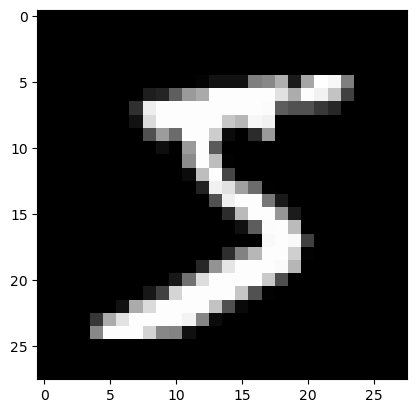

In [20]:
plt.imshow(num5, cmap='gray')

In [21]:
#Crear una mascara para encontrar el indice de las filas con el número 5


In [22]:
# Guardar alguna fila en una variable llamada num5


<function matplotlib.pyplot.show(close=None, block=None)>

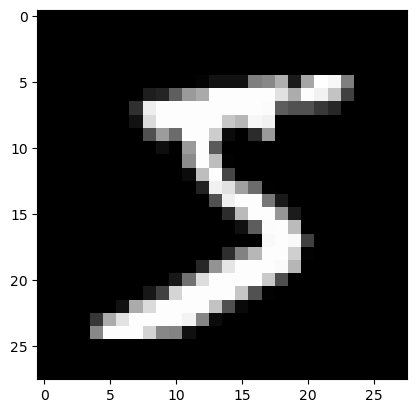

In [23]:
# Graficar la imagen del numero 5
plt.imshow(num5,cmap='gray')
plt.show

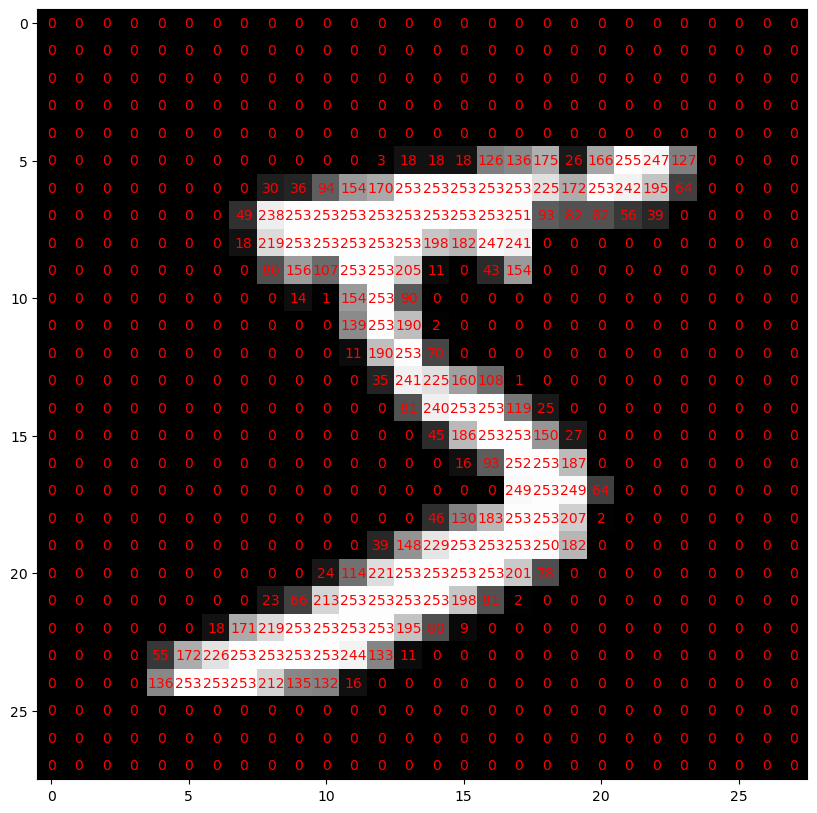

In [24]:
# mostrar los elementos que componen el arreglo sobre la imagen del numero 5
plt.figure(figsize=(10,10))
plt.imshow(num5,cmap='gray')
for (j,i), label in np.ndenumerate(num5):
    plt.text(i,j,label,ha='center',va='center',color='red')
plt.show()

## 3. Prepare los datos 

#### División general de los datos


<img  align="middle" style="width:350px;" src="figuras/ml_diagrama3.jpg">



* **X**: Datos sin el diagnostico es decir sin la columna "target"
* **y**: Datos con el diagnostico es decir con la columna "target"

Muestras de entrenamiento y prueba
* **X_train**: este será el grupo de entrenamiento
* **X_test**: este será el  grupo de prueba
* **y_train**: este será el target para el grupo de entrenamiento
* **y_test**: este será el target para el grupo de prueba

In [25]:
# Definir los conjuntos de datos de las muestras de entrenamiento y prueba
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]

X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]

## 4. Definimos el pipeline y el clasificador

<img src="figuras/pipeline.jpg" align="middle" style="width:500px;" />

In [26]:
#Definir el pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

steps = [ ('scaler', StandardScaler()),
         ('SVM', SVC(kernel='poly'))]

modelo_SVM = Pipeline(steps)

## 5. Realizamos el tuning 

In [27]:
#Parámetros
# C = [0.0001,0.001]
# gamma = [20,10]

parametros = {
    'SVM__C': [0.0001, 0.001],
    'SVM__gamma': [20,10]
}

In [28]:
#Realizar el tuning
from sklearn.model_selection import GridSearchCV

grid_SVM =  GridSearchCV(modelo_SVM, param_grid=parametros, cv=5, n_jobs=-1)


In [29]:
#Ajuste
grid_SVM.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...nel='poly'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'SVM__C': [0.0001, 0.001], 'SVM__gamma': [20, 10]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fo

In [30]:
#mostrar los mejores valores del tuning
grid_SVM.best_params_

{'SVM__C': 0.0001, 'SVM__gamma': 20}

## 6. Probamos el clasificador SVM

**Exactitud (Accuracy)**:
La exactitud es una medida de la proporción de predicciones correctas que realiza el modelo sobre el total de predicciones realizadas. Se calcula como la proporción entre el número de predicciones correctas y el número total de predicciones. Matemáticamente, se expresa como:


<img align="left" style="padding-right:5px;" src="figuras/img_accuracy.png">


In [31]:
# Realizar la predicción en los datos de test
y_pred = grid_SVM.predict(X_test)
y_pred

array([7, 2, 1, 0, 4, 1, 4, 9, 4, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6,
       6, 5, 4, 0, 9, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 8, 1, 1, 7, 4, 4,
       3, 5, 1, 2, 4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3, 7, 4,
       6, 4, 3, 0, 7, 0, 2, 9, 1, 7, 3, 2, 9, 7, 9, 6, 2, 7, 8, 4, 7, 3,
       6, 1, 3, 6, 4, 3, 1, 4, 1, 1, 6, 9, 6, 0, 5, 4, 9, 9, 2, 1, 9, 4,
       8, 7, 3, 9, 7, 9, 4, 4, 9, 9, 5, 4, 7, 6, 7, 9, 0, 5, 8, 5, 6, 6,
       5, 7, 8, 1, 0, 1, 6, 4, 6, 7, 3, 1, 7, 1, 8, 2, 0, 4, 9, 9, 5, 5,
       1, 5, 6, 0, 3, 4, 4, 6, 5, 4, 4, 5, 4, 5, 1, 4, 4, 7, 2, 3, 2, 7,
       1, 8, 1, 8, 1, 8, 5, 0, 8, 9, 2, 5, 0, 1, 1, 1, 0, 4, 0, 9, 1, 6,
       4, 2, 3, 6, 1, 1, 1, 3, 9, 5, 2, 9, 4, 5, 9, 3, 9, 0, 3, 5, 5, 5,
       7, 2, 2, 7, 1, 2, 8, 4, 1, 7, 5, 3, 8, 7, 7, 9, 2, 2, 4, 1, 5, 8,
       8, 7, 4, 1, 0, 4, 4, 2, 4, 1, 9, 5, 7, 7, 2, 8, 2, 6, 8, 5, 7, 7,
       4, 1, 8, 1, 8, 0, 3, 0, 1, 9, 9, 9, 1, 8, 2, 1, 2, 9, 7, 5, 9, 2,
       6, 4, 1, 5, 9, 2, 9, 2, 0, 4, 0, 0, 2, 8, 4,

In [32]:
y_test

0      7
1      2
2      1
3      0
4      4
      ..
496    9
497    4
498    0
499    6
500    3
Name: 0, Length: 501, dtype: uint8

In [33]:
# Los guardamos en una archivo llamado  mnist_prediccion_clase.txt
np.savetxt('mnist_prediccion_clase.txt', y_pred, fmt='%d', delimiter=',')

In [34]:
y_test

0      7
1      2
2      1
3      0
4      4
      ..
496    9
497    4
498    0
499    6
500    3
Name: 0, Length: 501, dtype: uint8

In [35]:
#Mostramos el accuracy_score
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)



0.8982035928143712

In [36]:
#mostrar la predicción para los primeros 10 valores de prueba


In [37]:
#mostrar los valores reales de los primeros 10 valores de prueba


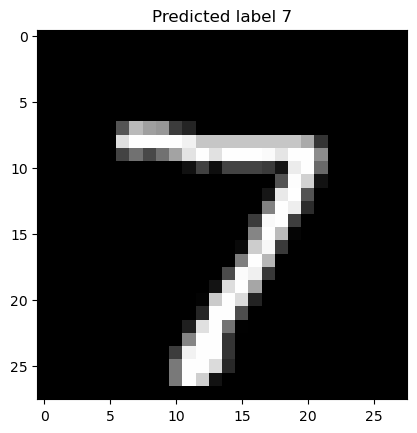

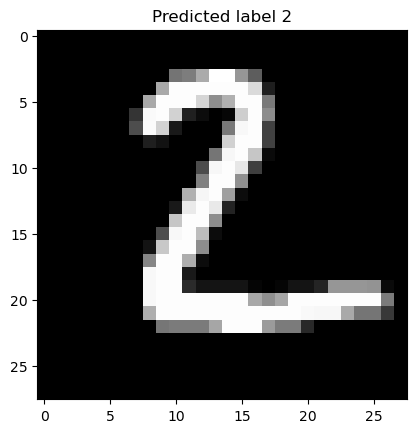

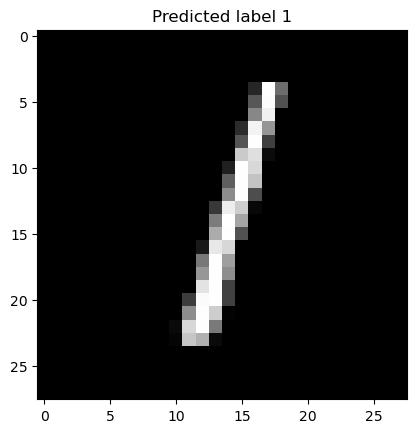

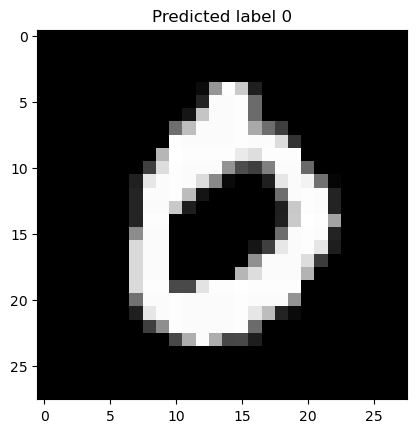

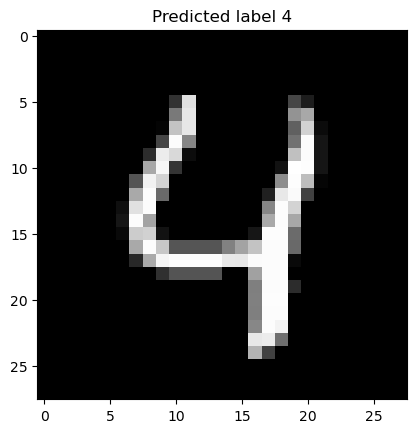

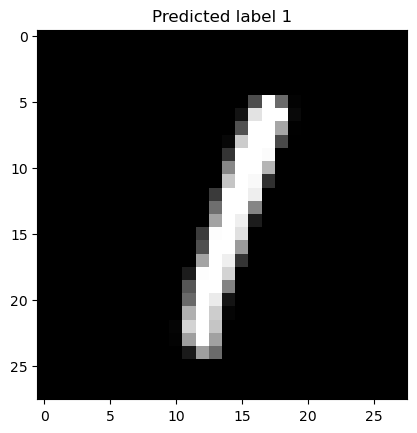

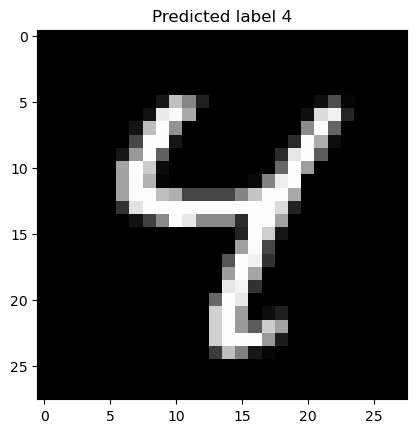

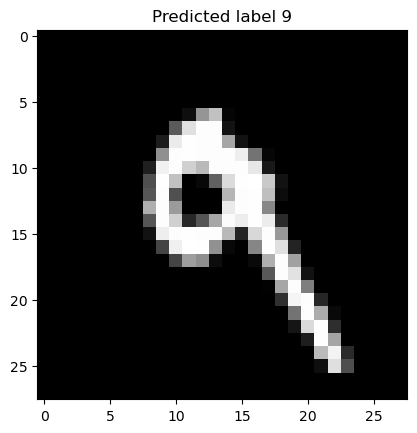

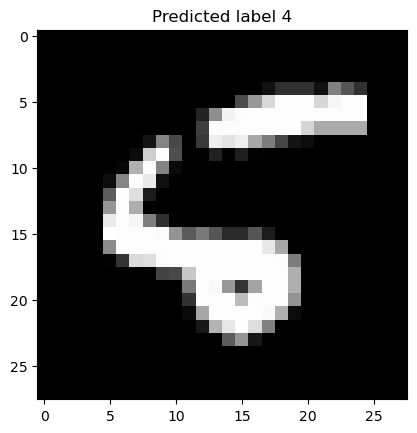

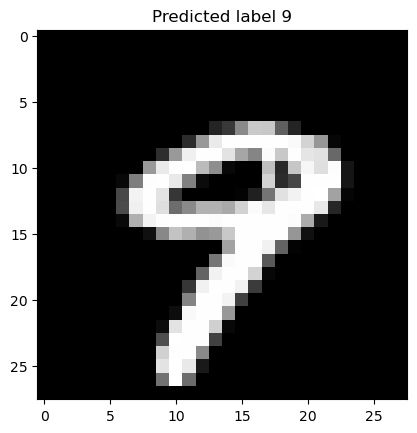

In [38]:
#Mostrar la prediccion y el número
for i in range(10):
    img=X_test.values[i].reshape((28,28))
    plt.title('Predicted label {0}'.format(y_pred[i]))
    plt.imshow(img,cmap='gray')
    plt.show()

### Probamos el clasificador SVM en nuestros propios números

In [39]:
#Cargar el archivo de mis números 'datos/mis_numeros.csv'
df_mn = pd.read_csv('./datos/mis_numeros_Carlos_Chavarria.csv', header=None, dtype='uint8')
df_mn.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
#Definir una variable X e y para nuestros números
X_mn = df_mn.iloc[:,1:]
y_mn = df_mn.iloc[:,0]

In [41]:
#Realizar la predicción en nuestros números
y_pred_mn = grid_SVM.predict(X_mn)

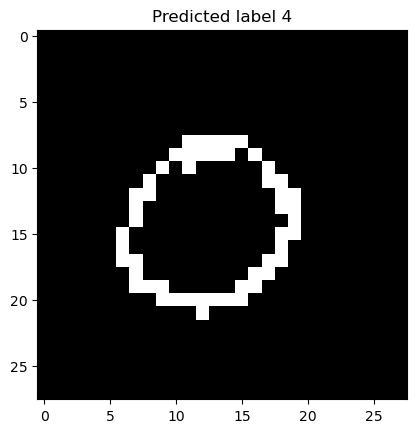

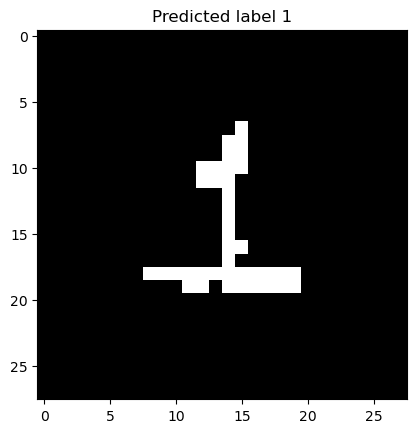

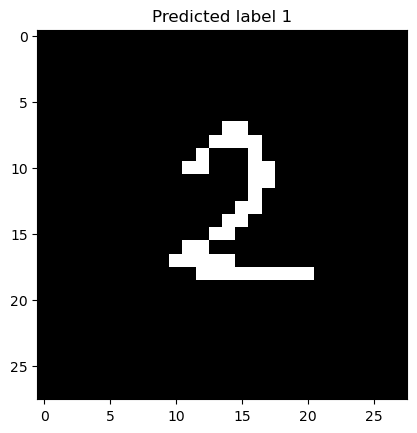

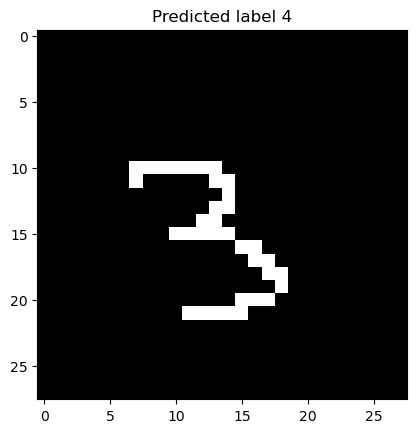

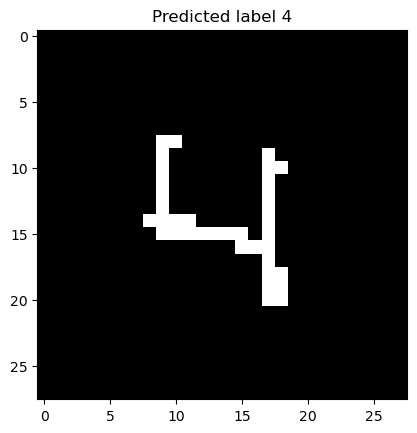

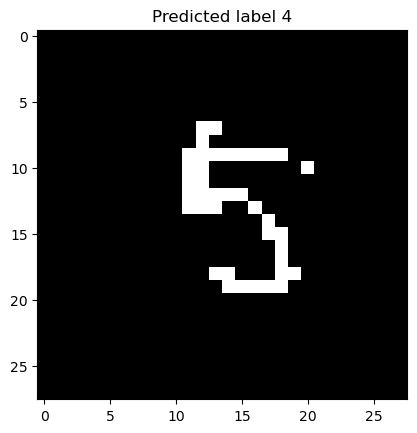

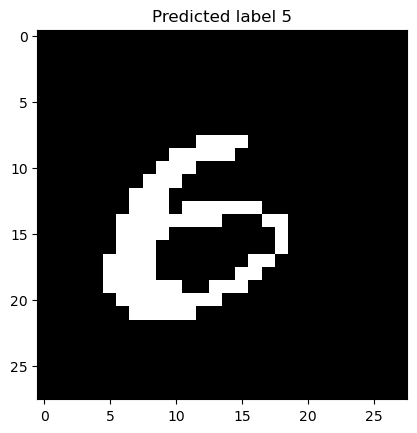

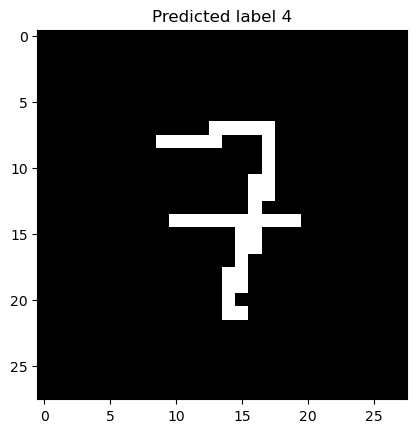

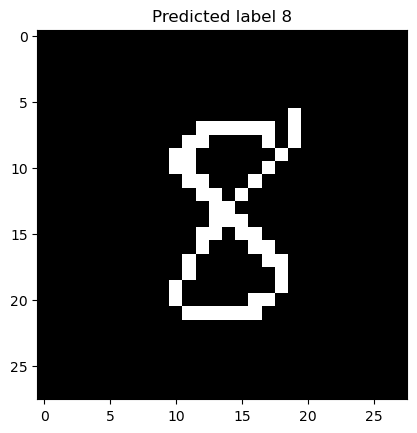

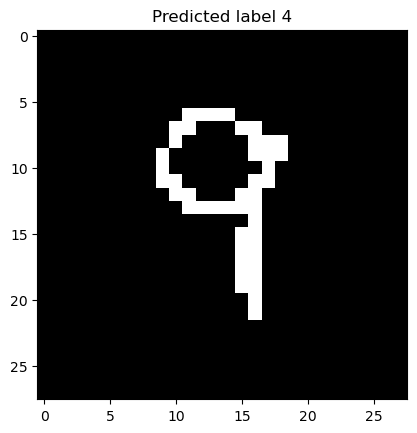

In [42]:
# Comparar la predicción con los valores reales
for i in range(10):
    img=X_mn.values[i].reshape((28,28))
    plt.title('Predicted label {0}'.format(y_pred_mn[i]))
    plt.imshow(img,cmap='gray')
    plt.show()

## 7. Matriz de confusión

### Casos posibles


Tomamos elementos de la muestra de prueba o test
<img src="figuras/PositivosNegativos.png" align="middle" style="width:650px;"/></td>

### Caso 1 : Verdaderos Negativos (VN)

Cuando los negativos que fueron clasificados correctamente como negativos por el modelo.

<img src="figuras/caso1.jpg" align="middle" style="width:750px;"/></td>


### Caso 2 : Verdaderos Positivos (VP)

Cuando los positivos que fueron clasificados correctamente como positivos por el modelo.

<img src="figuras/caso2.jpg" align="middle" style="width:750px;"/></td>

### Caso 3 : Falsos Positivos (FP)

Cuando los negativos que fueron clasificados incorrectamente como positivos. Error tipo 1 (Falsos positivos)

<img src="figuras/caso3.jpg" align="middle" style="width:750px;"/></td>


### Caso 4 : Falsos Negativos

Cuando los positivos que fueron clasificados incorrectamente como negativos. Error tipo 2 (Falsos Negativos)

<img src="figuras/caso4a.jpg" align="middle" style="width:750px;"/></td>



### Matriz de confusión 

La matriz de confusión es una herramienta que permite la visualización del desempeño de un algoritmo de ML. Cada columna de la matriz representa las predicciones de cada clase, mientras que cada fila representa a las instancias reales. Uno de los beneficios de las matrices de confusión es que facilitan ver si el sistema está confundiendo las diferentes clases o resultadosde la clasificación.

<br>

<img src="figuras/Matriz_resumen_s.jpg" align="middle" style="width:550px;"/></td>


#### Sobre los datos de prueba  MNIST

In [46]:
from sklearn.metrics import confusion_matrix

<Axes: xlabel='Predicted', ylabel='Actual'>

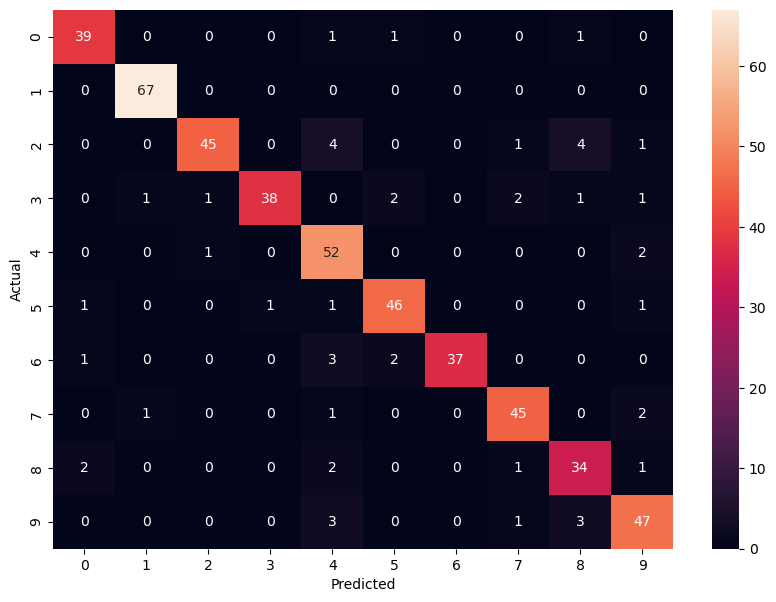

In [47]:
import seaborn as sn
import matplotlib.pyplot as plt
import pandas as pd
array=confusion_matrix(y_test,y_pred)
df_cm=pd.DataFrame(array,index=[i for i in range(10)],
                  columns=[i for i in range(10)])
df_cm.index.name='Actual'
df_cm.columns.name='Predicted'
plt.figure(figsize=(10,7))
sn.heatmap(df_cm, annot=True,fmt='d')

#### 1. Utilizando el mismo procedimiento del tutorial , encontrar la matriz de confusión para sus números. 

In [49]:
df_mn=pd.read_csv('./datos/mis_numeros_Carlos_Chavarria.csv',header=None,dtype='uint8')
X_mn=df_mn.iloc[:,1:]
y_mn=df_mn.iloc[:,0]
y_pred_mn=grid_SVM.predict(X_mn)

<Axes: xlabel='Predicted', ylabel='Actual'>

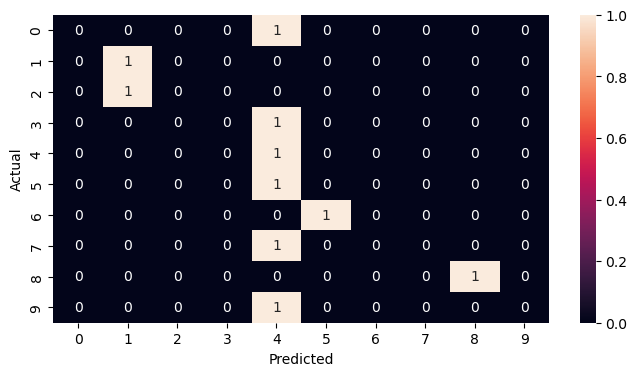

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sn

array=confusion_matrix(y_mn,y_pred_mn)
df_cm=pd.DataFrame(array,index=[i for i in range(10)],
                  columns=[i for i in range(10)])
df_cm.index.name='Actual'
df_cm.columns.name='Predicted'
plt.figure(figsize=(8,4))
sn.heatmap(df_cm, annot=True)

#  Tarea:
* Encontrar un modelo de aprendizaje automático con el mejor desempeño posible para los datos de entrenamiento (datos/mnist_train_tarea.txt) y prueba (datos/mnist_test_tarea.txt).
* Evaluar el modelo en sus números personales y encontrar la matriz de confusión.
* Evaluar el archivo datos/mnist_evaluacion_pixeles.txt, asignar etiquetas a los datos y guardar los resultados en un archivo de texto.
     * np.savetxt('NOMBRE1_NOMBRE2_NOMBRE3.txt', y_pred, fmt='%d', delimiter=',')